# ================================================
# FILE 5: ANALISIS PERBANDINGAN KOMPREHENSIF LSTM vs BI-LSTM
# ================================================
# Penelitian : Perbandingan LSTM vs Bi-LSTM untuk Analisis Sentimen MBG
# Input      : results_lstm.csv & results_bilstm.csv
# Output     : comparison_table.csv, visualisasi komprehensif, & uji statistik
# Platform   : Google Colab
# ================================================

### BAGIAN 0 — SETUP & INSTALASI

In [1]:
# ==========================================
# BAGIAN 0: SETUP & INSTALASI
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR  = '/content/drive/MyDrive/skripsi_mbg'
COMP_DIR  = f'{BASE_DIR}/results_comparison'
os.makedirs(COMP_DIR, exist_ok=True)

print("=" * 70)
print("FILE 5: ANALISIS PERBANDINGAN LSTM vs BI-LSTM")
print("=" * 70)


Mounted at /content/drive
FILE 5: ANALISIS PERBANDINGAN LSTM vs BI-LSTM


### BAGIAN 1 — LOAD HASIL EVALUASI

In [2]:
# ==========================================
# BAGIAN 1: LOAD HASIL KEDUA MODEL
# ==========================================
print("\n" + "=" * 70)
print("BAGIAN 1: LOAD HASIL EVALUASI")
print("=" * 70)

# PERBAIKAN PATH: Mengarah ke folder data/results/ sesuai output training sebelumnya
df_lstm   = pd.read_csv(f'{BASE_DIR}/data/results/results_lstm.csv')
df_bilstm = pd.read_csv(f'{BASE_DIR}/data/results/results_bilstm.csv')

print(f"✅ results_lstm.csv   : {len(df_lstm)} skenario")
print(f"✅ results_bilstm.csv : {len(df_bilstm)} skenario")

print(f"\nKolom LSTM   : {df_lstm.columns.tolist()}")
print(f"Kolom BiLSTM : {df_bilstm.columns.tolist()}")



BAGIAN 1: LOAD HASIL EVALUASI
✅ results_lstm.csv   : 4 skenario
✅ results_bilstm.csv : 4 skenario

Kolom LSTM   : ['model', 'skenario_id', 'skenario', 'accuracy', 'precision', 'recall', 'f1_score', 'confusion_matrix', 'classification_report', 'precision_NEGATIVE', 'recall_NEGATIVE', 'f1_NEGATIVE', 'precision_NEUTRAL', 'recall_NEUTRAL', 'f1_NEUTRAL', 'precision_POSITIVE', 'recall_POSITIVE', 'f1_POSITIVE', 'epoch_digunakan', 'epoch_maksimal', 'units', 'train_accuracy', 'val_accuracy', 'train_loss', 'val_loss', 'total_params']
Kolom BiLSTM : ['model', 'skenario_id', 'skenario', 'accuracy', 'precision', 'recall', 'f1_score', 'confusion_matrix', 'classification_report', 'precision_NEGATIVE', 'recall_NEGATIVE', 'f1_NEGATIVE', 'precision_NEUTRAL', 'recall_NEUTRAL', 'f1_NEUTRAL', 'precision_POSITIVE', 'recall_POSITIVE', 'f1_POSITIVE', 'epoch_digunakan', 'epoch_maksimal', 'units', 'train_accuracy', 'val_accuracy', 'train_loss', 'val_loss', 'total_params']


### BAGIAN 2 — BUAT TABEL PERBANDINGAN

In [3]:
# ==========================================
# BAGIAN 2: BUAT TABEL PERBANDINGAN
# ==========================================
'''
Membuat tabel perbandingan komprehensif antara LSTM dan Bi-LSTM
untuk setiap skenario dan setiap metrik evaluasi
'''
print("\n" + "=" * 70)
print("BAGIAN 2: TABEL PERBANDINGAN LSTM vs BI-LSTM")
print("=" * 70)

# Metrics yang akan dibandingkan
metrics = ['accuracy', 'precision', 'recall', 'f1_score']

# Buat tabel perbandingan untuk setiap skenario
comparison_rows = []

for i in range(len(df_lstm)):
    row_lstm   = df_lstm.iloc[i]
    row_bilstm = df_bilstm.iloc[i]

    row = {
        'Skenario'         : row_lstm['skenario'],
        'Epoch'            : int(row_lstm['epoch_digunakan']),
        'Units'            : int(row_lstm['units']),

        # LSTM metrics
        'LSTM_Accuracy'    : row_lstm['accuracy'],
        'LSTM_Precision'   : row_lstm['precision'],
        'LSTM_Recall'      : row_lstm['recall'],
        'LSTM_F1'          : row_lstm['f1_score'],

        # BiLSTM metrics
        'BiLSTM_Accuracy'  : row_bilstm['accuracy'],
        'BiLSTM_Precision' : row_bilstm['precision'],
        'BiLSTM_Recall'    : row_bilstm['recall'],
        'BiLSTM_F1'        : row_bilstm['f1_score'],

        # Selisih (positif = BiLSTM lebih baik)
        'Delta_Accuracy'   : round(row_bilstm['accuracy'] - row_lstm['accuracy'], 4),
        'Delta_Precision'  : round(row_bilstm['precision'] - row_lstm['precision'], 4),
        'Delta_Recall'     : round(row_bilstm['recall'] - row_lstm['recall'], 4),
        'Delta_F1'         : round(row_bilstm['f1_score'] - row_lstm['f1_score'], 4),

        # Pemenang per skenario
        'Winner'           : 'BiLSTM' if row_bilstm['accuracy'] > row_lstm['accuracy']
                             else ('LSTM' if row_lstm['accuracy'] > row_bilstm['accuracy']
                             else 'Tie')
    }
    comparison_rows.append(row)

df_comparison = pd.DataFrame(comparison_rows)

# Tampilkan tabel perbandingan
print("\nTabel Perbandingan Metrik Evaluasi:")
print(f"\n{'='*90}")
print(f"{'Skenario':<13} {'Ep':>4} {'Un':>4} │ "
      f"{'LSTM Acc':>9} {'LSTM F1':>8} │ "
      f"{'BiLSTM Acc':>10} {'BiLSTM F1':>9} │ "
      f"{'ΔAcc':>6} {'ΔF1':>6} │ {'Winner':>7}")
print(f"{'─'*90}")

for _, row in df_comparison.iterrows():
    print(f"{row['Skenario']:<13} {row['Epoch']:>4} {row['Units']:>4} │ "
          f"{row['LSTM_Accuracy']:>9.4f} {row['LSTM_F1']:>8.4f} │ "
          f"{row['BiLSTM_Accuracy']:>10.4f} {row['BiLSTM_F1']:>9.4f} │ "
          f"{row['Delta_Accuracy']:>+6.4f} {row['Delta_F1']:>+6.4f} │ "
          f"{row['Winner']:>7}")

print(f"{'='*90}")

# Rata-rata semua skenario
print(f"\n{'RATA-RATA':<13} {'':>4} {'':>4} │ "
      f"{df_comparison['LSTM_Accuracy'].mean():>9.4f} {df_comparison['LSTM_F1'].mean():>8.4f} │ "
      f"{df_comparison['BiLSTM_Accuracy'].mean():>10.4f} {df_comparison['BiLSTM_F1'].mean():>9.4f} │ "
      f"{df_comparison['Delta_Accuracy'].mean():>+6.4f} {df_comparison['Delta_F1'].mean():>+6.4f} │ "
      f"{'':>7}")

# Kesimpulan pemenang
bilstm_wins = (df_comparison['Winner'] == 'BiLSTM').sum()
lstm_wins   = (df_comparison['Winner'] == 'LSTM').sum()
ties        = (df_comparison['Winner'] == 'Tie').sum()

print(f"\nRekapitulasi Pemenang per Skenario:")
print(f"  Bi-LSTM menang : {bilstm_wins}/{len(df_comparison)} skenario")
print(f"  LSTM menang    : {lstm_wins}/{len(df_comparison)} skenario")
print(f"  Seri           : {ties}/{len(df_comparison)} skenario")



BAGIAN 2: TABEL PERBANDINGAN LSTM vs BI-LSTM

Tabel Perbandingan Metrik Evaluasi:

Skenario        Ep   Un │  LSTM Acc  LSTM F1 │ BiLSTM Acc BiLSTM F1 │   ΔAcc    ΔF1 │  Winner
──────────────────────────────────────────────────────────────────────────────────────────
Skenario 1      20   64 │    0.6503   0.5840 │     0.6036    0.4648 │ -0.0467 -0.1192 │    LSTM
Skenario 2      19   64 │    0.6036   0.4543 │     0.6036    0.4543 │ +0.0000 +0.0000 │     Tie
Skenario 3      25   64 │    0.5902   0.4563 │     0.5947    0.4662 │ +0.0045 +0.0099 │  BiLSTM
Skenario 4      20  128 │    0.5590   0.5013 │     0.5924    0.4775 │ +0.0334 -0.0238 │  BiLSTM

RATA-RATA               │    0.6008   0.4990 │     0.5986    0.4657 │ -0.0022 -0.0333 │        

Rekapitulasi Pemenang per Skenario:
  Bi-LSTM menang : 2/4 skenario
  LSTM menang    : 1/4 skenario
  Seri           : 1/4 skenario


### BAGIAN 3 — UJI STATISTIK

In [4]:
# ==========================================
# BAGIAN 3: UJI STATISTIK
# ==========================================
'''
Uji statistik untuk menentukan apakah perbedaan kinerja
antara LSTM dan Bi-LSTM signifikan secara statistik

Tests yang digunakan:
1. Paired t-test: Membandingkan mean dua model yang berkorelasi
   (data latih yang sama, test yang sama)
2. Wilcoxon Signed-Rank Test: Uji non-parametrik alternatif
   Lebih robust untuk sample kecil (n=4 skenario)
'''
print("\n" + "=" * 70)
print("BAGIAN 3: UJI STATISTIK")
print("=" * 70)

print("\n⚠️ Catatan: Dengan hanya 4 skenario, uji statistik bersifat indikatif. Interpretasikan dengan hati-hati.")

alpha = 0.05
statistical_results = {}

print(f"\n{'─'*60}")
print(f"Hipotesis:")
print(f"  H0: Tidak ada perbedaan signifikan LSTM vs Bi-LSTM")
print(f"  H1: Ada perbedaan signifikan LSTM vs Bi-LSTM")
print(f"  α  = {alpha} (tingkat signifikansi)")
print(f"{'─'*60}")

for metric in metrics:
    # Map nama kolom
    col_map = {
        'accuracy' : ('LSTM_Accuracy', 'BiLSTM_Accuracy'),
        'precision': ('LSTM_Precision', 'BiLSTM_Precision'),
        'recall'   : ('LSTM_Recall', 'BiLSTM_Recall'),
        'f1_score' : ('LSTM_F1', 'BiLSTM_F1'),
    }

    lstm_vals   = df_comparison[col_map[metric][0]].values
    bilstm_vals = df_comparison[col_map[metric][1]].values

    # Paired t-test
    t_stat, p_ttest = stats.ttest_rel(lstm_vals, bilstm_vals)

    # Wilcoxon signed-rank test
    try:
        w_stat, p_wilcoxon = stats.wilcoxon(lstm_vals, bilstm_vals)
    except ValueError:
        # Jika semua nilai sama
        w_stat, p_wilcoxon = 0, 1.0

    significant_ttest    = p_ttest < alpha
    significant_wilcoxon = p_wilcoxon < alpha

    statistical_results[metric] = {
        't_statistic'         : round(float(t_stat), 4) if not np.isnan(t_stat) else 0.0,
        'p_value_ttest'       : round(float(p_ttest), 4) if not np.isnan(p_ttest) else 1.0,
        'w_statistic'         : round(float(w_stat), 4),
        'p_value_wilcoxon'    : round(float(p_wilcoxon), 4),
        'significant_ttest'   : bool(significant_ttest),
        'significant_wilcoxon': bool(significant_wilcoxon),
        'mean_lstm'           : round(float(lstm_vals.mean()), 4),
        'mean_bilstm'         : round(float(bilstm_vals.mean()), 4),
        'mean_difference'     : round(float(bilstm_vals.mean() - lstm_vals.mean()), 4),
    }

    print(f"\nMetrik: {metric.upper()}")
    print(f"  Mean LSTM   : {lstm_vals.mean():.4f}")
    print(f"  Mean BiLSTM : {bilstm_vals.mean():.4f}")
    print(f"  Selisih     : {bilstm_vals.mean() - lstm_vals.mean():+.4f}")
    print(f"\n  Paired t-test:")
    print(f"    t-statistic : {t_stat:.4f}")
    print(f"    p-value     : {p_ttest:.4f}")
    print(f"    Signifikan  : {'✅ YA (H0 ditolak)' if significant_ttest else '❌ TIDAK (H0 gagal ditolak)'}")
    print(f"\n  Wilcoxon Signed-Rank Test:")
    print(f"    W-statistic : {w_stat:.4f}")
    print(f"    p-value     : {p_wilcoxon:.4f}")
    print(f"    Signifikan  : {'✅ YA (H0 ditolak)' if significant_wilcoxon else '❌ TIDAK (H0 gagal ditolak)'}")



BAGIAN 3: UJI STATISTIK

⚠️ Catatan: Dengan hanya 4 skenario, uji statistik bersifat indikatif. Interpretasikan dengan hati-hati.

────────────────────────────────────────────────────────────
Hipotesis:
  H0: Tidak ada perbedaan signifikan LSTM vs Bi-LSTM
  H1: Ada perbedaan signifikan LSTM vs Bi-LSTM
  α  = 0.05 (tingkat signifikansi)
────────────────────────────────────────────────────────────

Metrik: ACCURACY
  Mean LSTM   : 0.6008
  Mean BiLSTM : 0.5986
  Selisih     : -0.0022

  Paired t-test:
    t-statistic : 0.1327
    p-value     : 0.9028
    Signifikan  : ❌ TIDAK (H0 gagal ditolak)

  Wilcoxon Signed-Rank Test:
    W-statistic : 3.0000
    p-value     : 1.0000
    Signifikan  : ❌ TIDAK (H0 gagal ditolak)

Metrik: PRECISION
  Mean LSTM   : 0.4735
  Mean BiLSTM : 0.3875
  Selisih     : -0.0859

  Paired t-test:
    t-statistic : 1.5796
    p-value     : 0.2123
    Signifikan  : ❌ TIDAK (H0 gagal ditolak)

  Wilcoxon Signed-Rank Test:
    W-statistic : 1.0000
    p-value     :

### BAGIAN 4 — VISUALISASI PERBANDINGAN


BAGIAN 4: VISUALISASI PERBANDINGAN


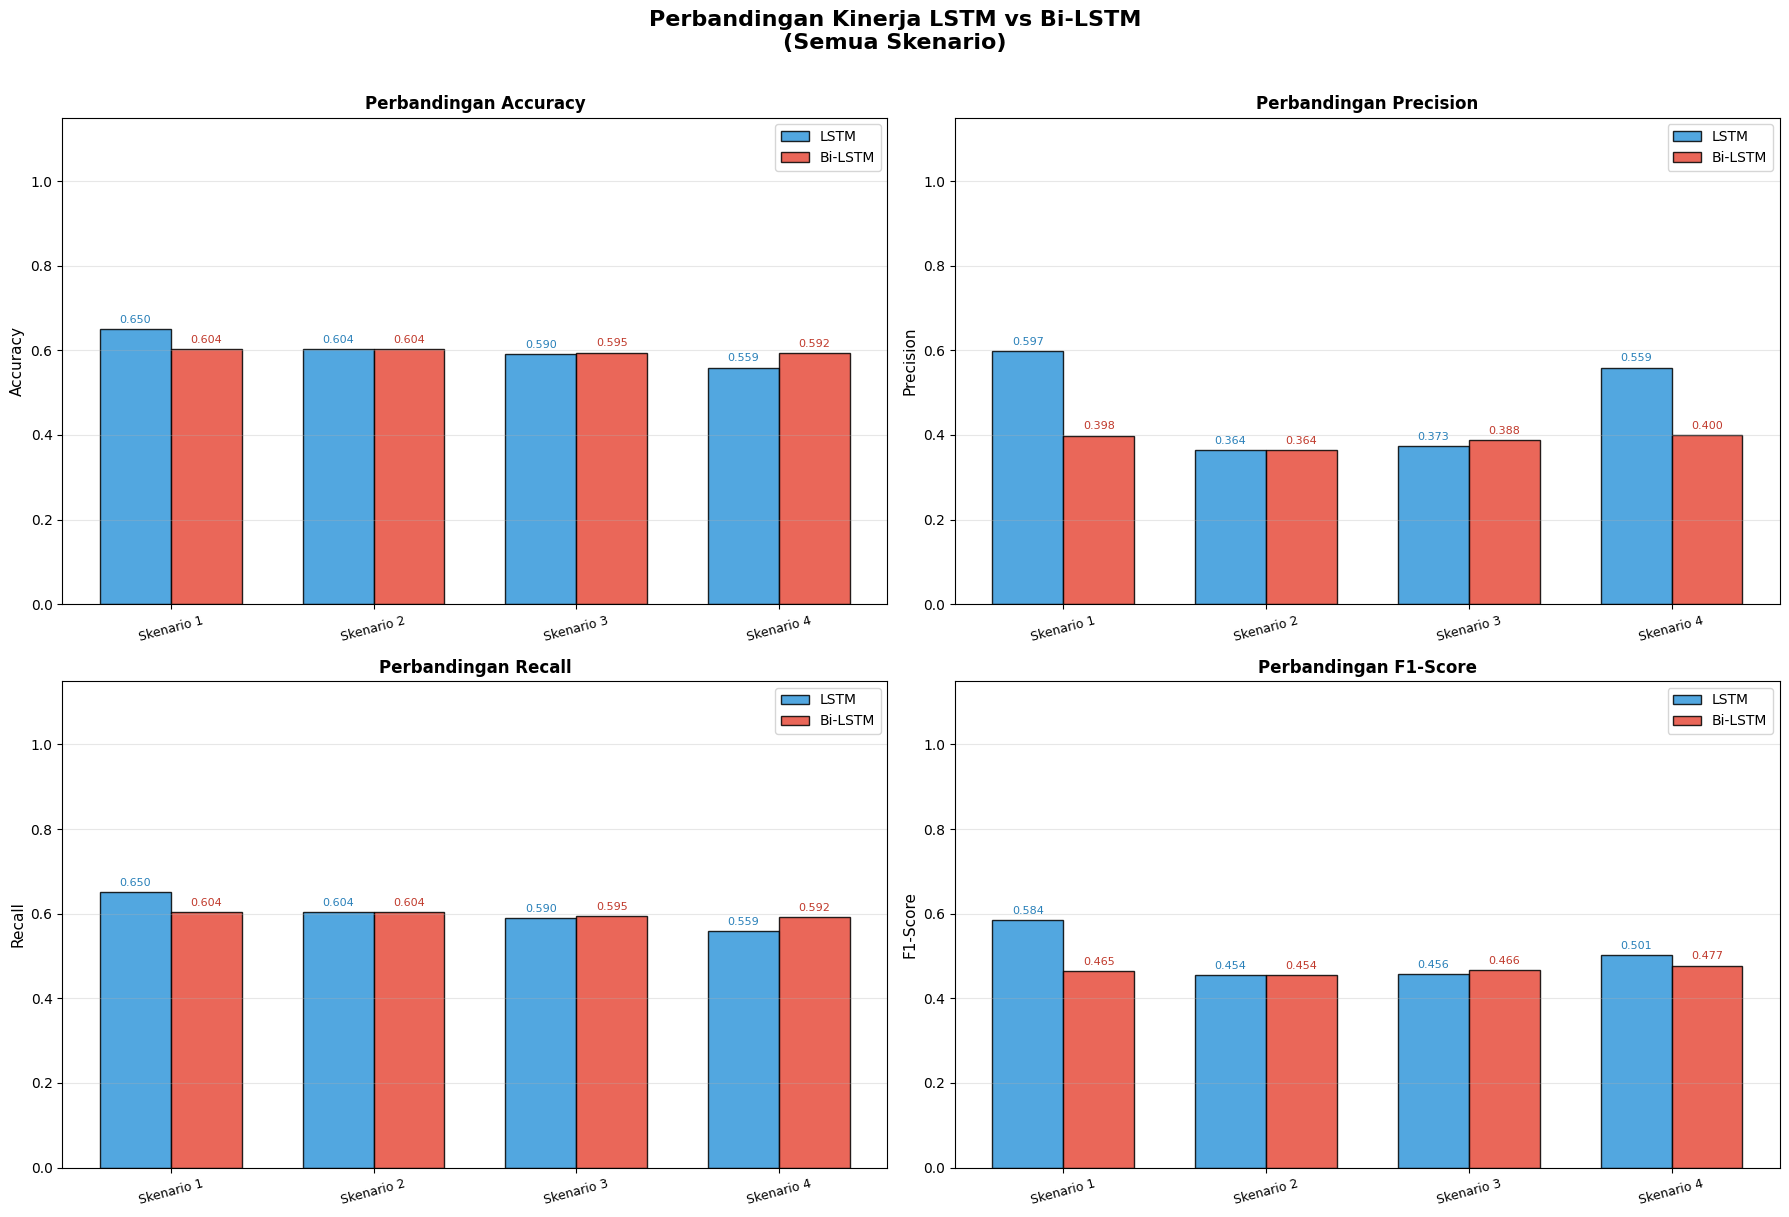

✅ comparison_grouped_bar.png tersimpan


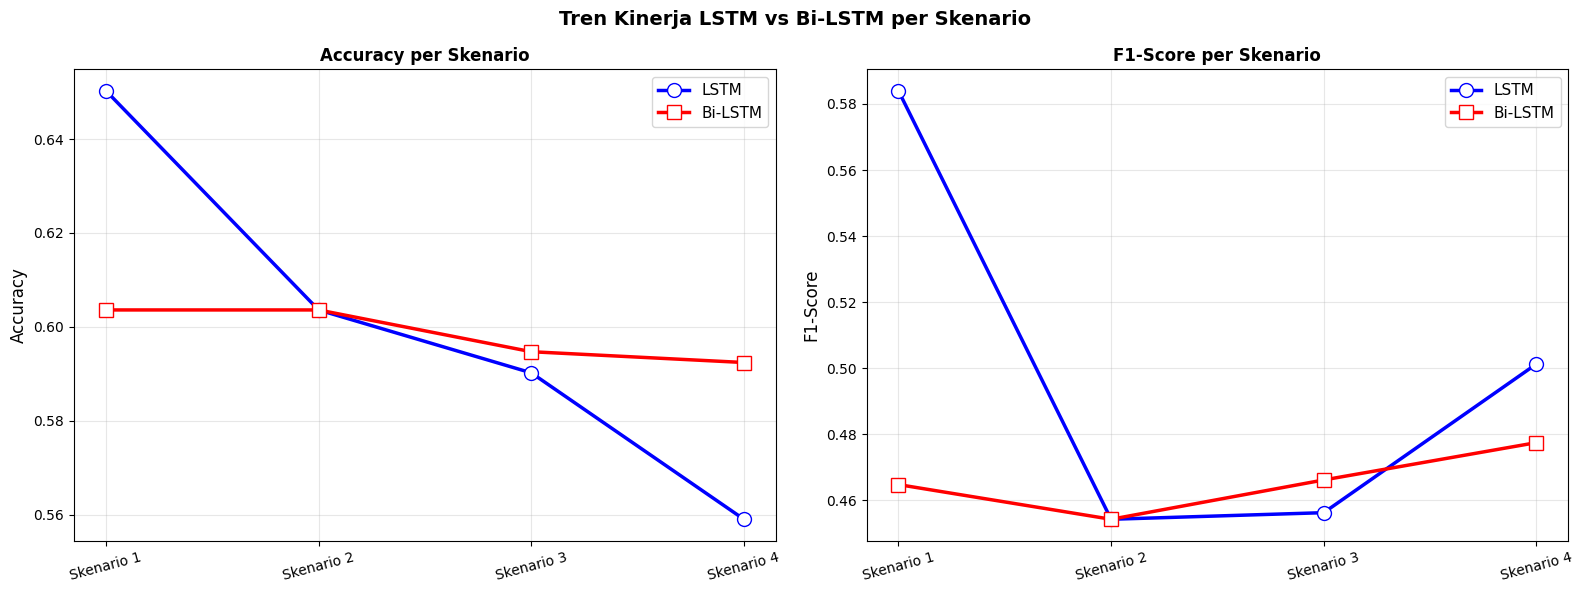

✅ comparison_line_plot.png tersimpan


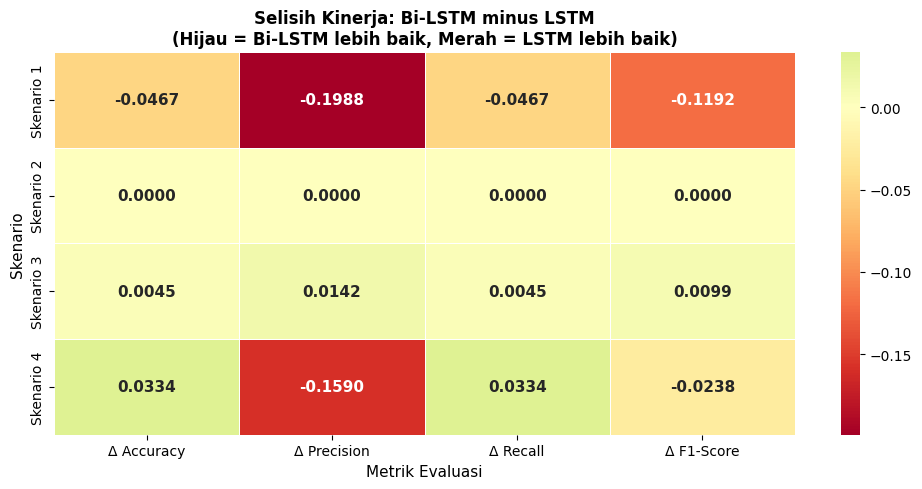

✅ comparison_delta_heatmap.png tersimpan


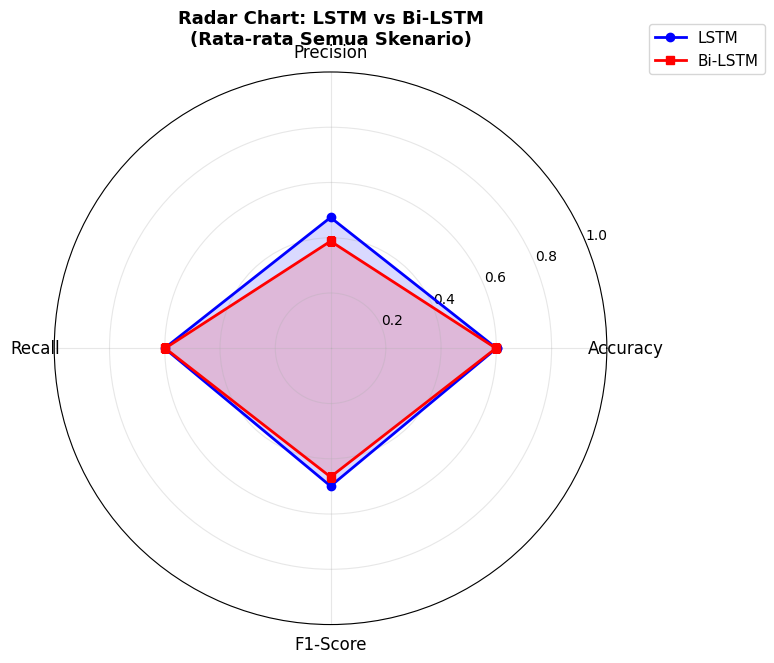

✅ comparison_radar_chart.png tersimpan


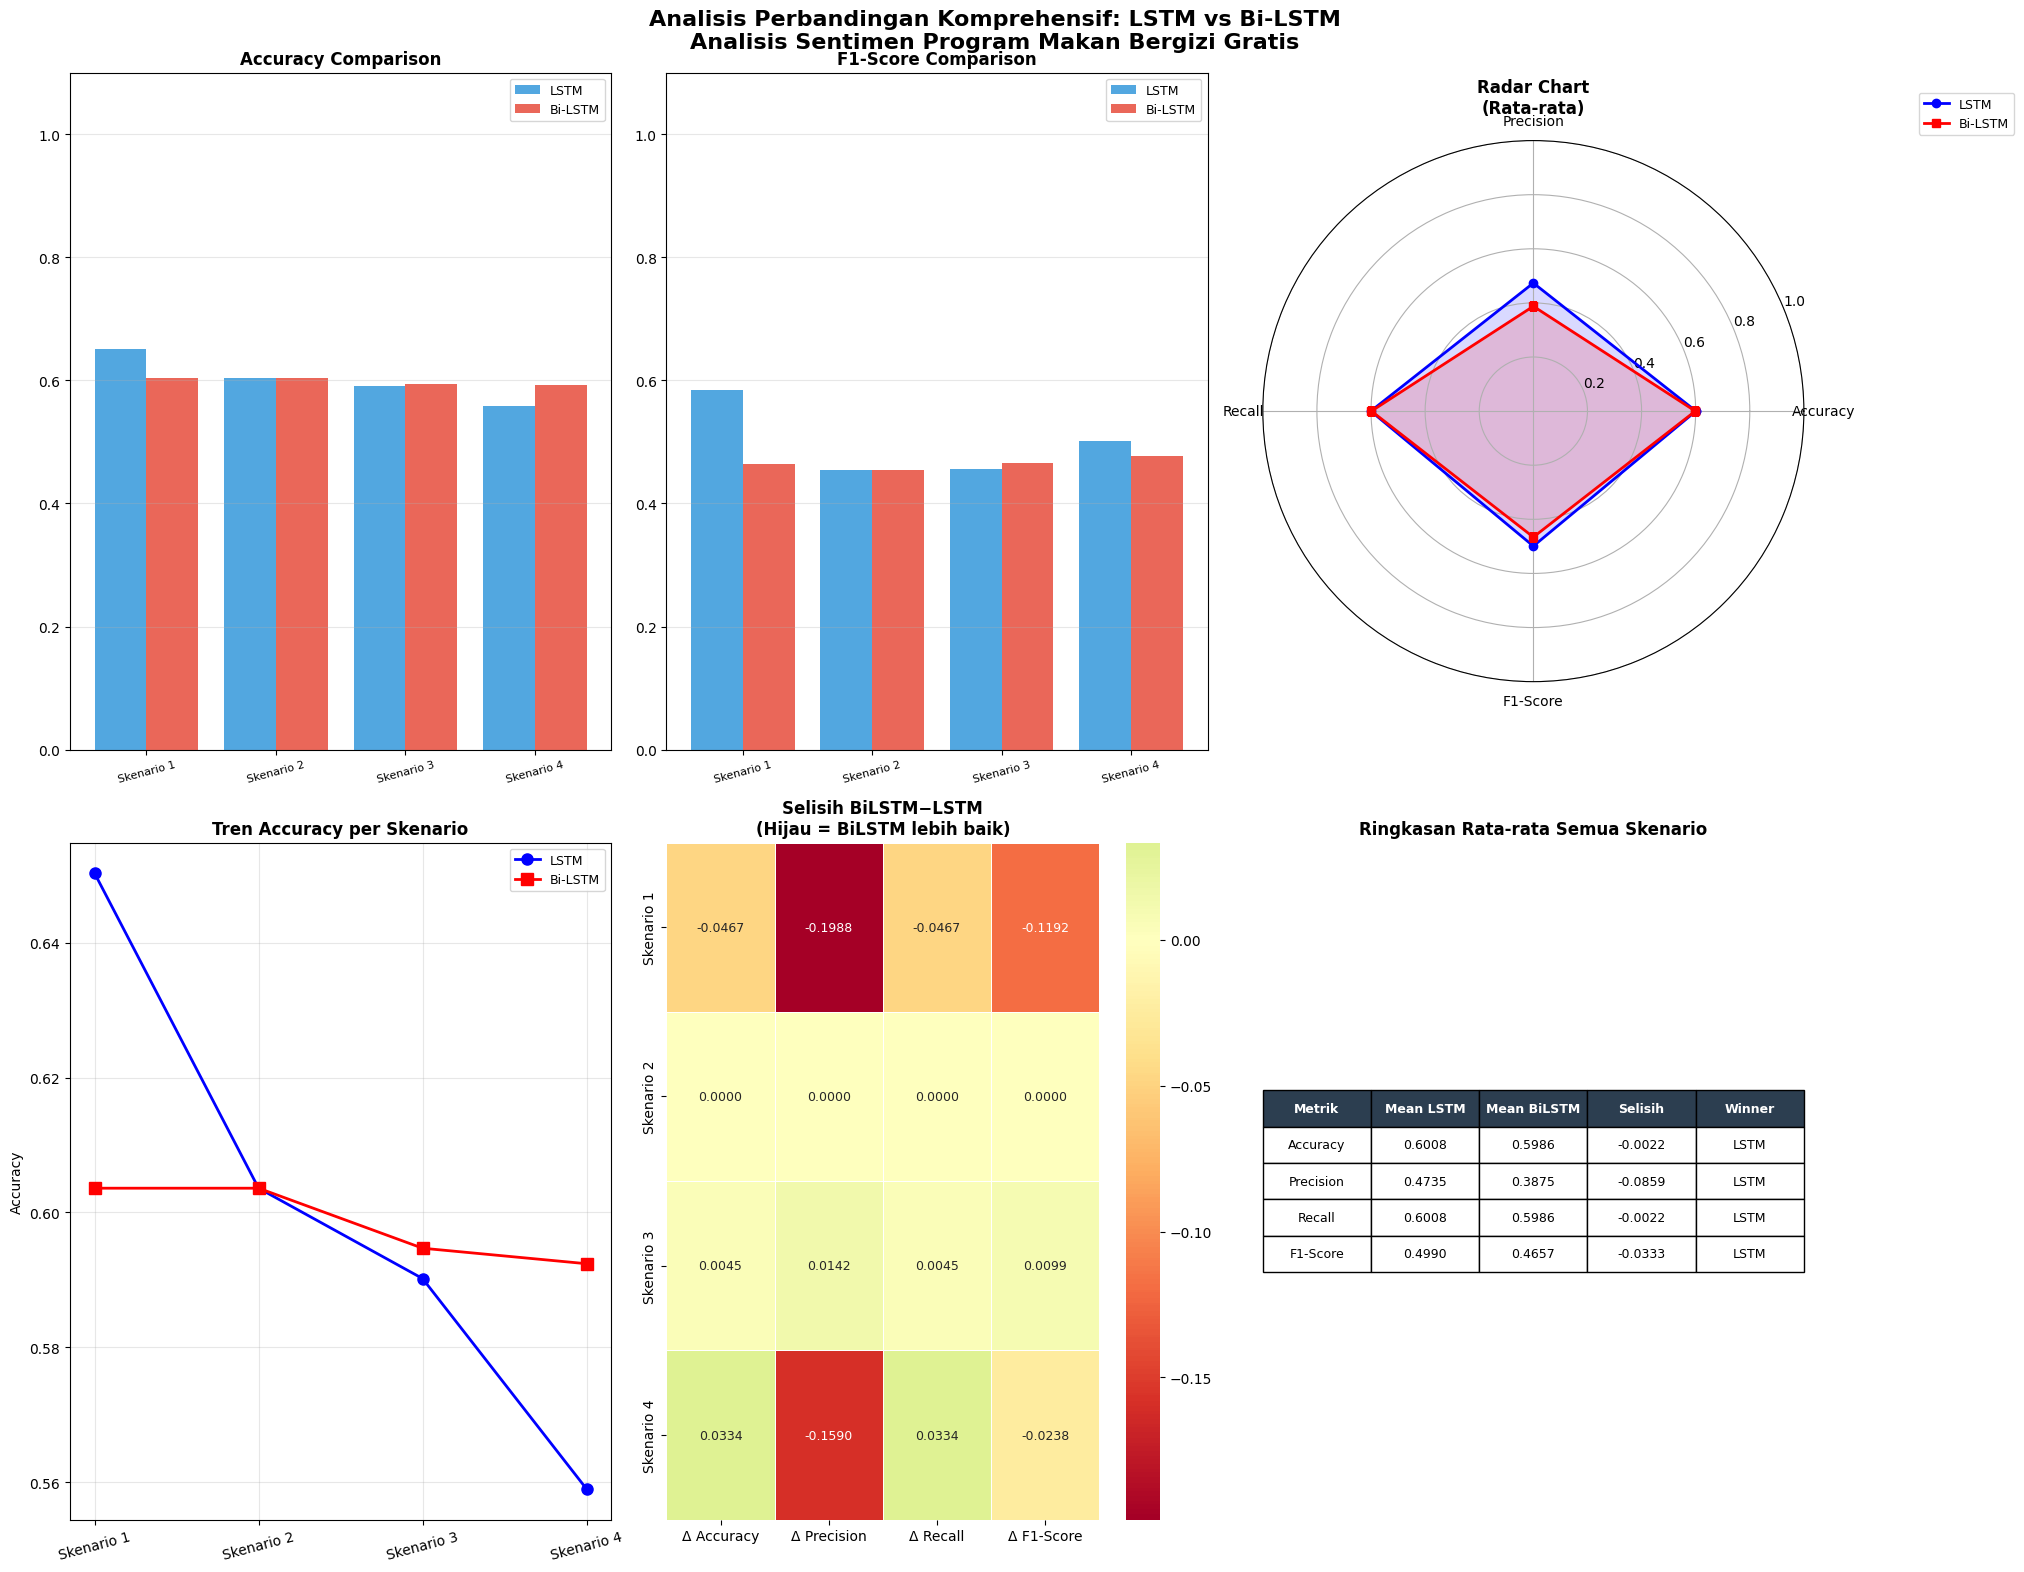

✅ comparison_plots.png (gabungan) tersimpan


In [5]:
# ==========================================
# BAGIAN 4: VISUALISASI PERBANDINGAN
# ==========================================
print("\n" + "=" * 70)
print("BAGIAN 4: VISUALISASI PERBANDINGAN")
print("=" * 70)

skenario_labels = df_comparison['Skenario'].tolist()
x = np.arange(len(skenario_labels))
width = 0.35

# ── PLOT 1: Grouped Bar Chart ──
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Perbandingan Kinerja LSTM vs Bi-LSTM\n(Semua Skenario)',
              fontsize=16, fontweight='bold', y=1.01)

col_pairs = [
    ('LSTM_Accuracy',  'BiLSTM_Accuracy',  'Accuracy'),
    ('LSTM_Precision', 'BiLSTM_Precision', 'Precision'),
    ('LSTM_Recall',    'BiLSTM_Recall',    'Recall'),
    ('LSTM_F1',        'BiLSTM_F1',        'F1-Score'),
]

for idx, (lstm_col, bilstm_col, title) in enumerate(col_pairs):
    ax = axes[idx // 2][idx % 2]

    lstm_vals   = df_comparison[lstm_col].values
    bilstm_vals = df_comparison[bilstm_col].values

    bars1 = ax.bar(x - width/2, lstm_vals,   width, label='LSTM',
                    color='#3498db', edgecolor='black', alpha=0.85)
    bars2 = ax.bar(x + width/2, bilstm_vals, width, label='Bi-LSTM',
                    color='#e74c3c', edgecolor='black', alpha=0.85)

    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'Perbandingan {title}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(skenario_labels, rotation=15, fontsize=9)
    ax.set_ylim([0, 1.15])
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # Nilai di atas bar
    for bar, val in zip(bars1, lstm_vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='#2980b9')
    for bar, val in zip(bars2, bilstm_vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='#c0392b')

plt.tight_layout()
plt.savefig(f'{COMP_DIR}/comparison_grouped_bar.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ comparison_grouped_bar.png tersimpan")

# ── PLOT 2: Line Plot Accuracy & F1-Score ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tren Kinerja LSTM vs Bi-LSTM per Skenario', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(skenario_labels, df_comparison['LSTM_Accuracy'],
              'b-o', linewidth=2.5, markersize=10, label='LSTM', markerfacecolor='white')
axes[0].plot(skenario_labels, df_comparison['BiLSTM_Accuracy'],
              'r-s', linewidth=2.5, markersize=10, label='Bi-LSTM', markerfacecolor='white')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy per Skenario', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)

# F1-Score
axes[1].plot(skenario_labels, df_comparison['LSTM_F1'],
              'b-o', linewidth=2.5, markersize=10, label='LSTM', markerfacecolor='white')
axes[1].plot(skenario_labels, df_comparison['BiLSTM_F1'],
              'r-s', linewidth=2.5, markersize=10, label='Bi-LSTM', markerfacecolor='white')
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_title('F1-Score per Skenario', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{COMP_DIR}/comparison_line_plot.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ comparison_line_plot.png tersimpan")

# ── PLOT 3: Heatmap Delta Metrics ──
fig, ax = plt.subplots(figsize=(10, 5))

delta_data = df_comparison[['Delta_Accuracy','Delta_Precision','Delta_Recall','Delta_F1']].values
delta_cols  = ['Δ Accuracy', 'Δ Precision', 'Δ Recall', 'Δ F1-Score']
delta_index = df_comparison['Skenario'].tolist()

df_heatmap = pd.DataFrame(delta_data, columns=delta_cols, index=delta_index)

sns.heatmap(df_heatmap, annot=True, fmt='.4f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})

ax.set_title('Selisih Kinerja: Bi-LSTM minus LSTM\n(Hijau = Bi-LSTM lebih baik, Merah = LSTM lebih baik)',
              fontsize=12, fontweight='bold')
ax.set_xlabel('Metrik Evaluasi', fontsize=11)
ax.set_ylabel('Skenario', fontsize=11)

plt.tight_layout()
plt.savefig(f'{COMP_DIR}/comparison_delta_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ comparison_delta_heatmap.png tersimpan")

# ── PLOT 4: Radar Chart ──
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(polar=True))

categories  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N           = len(categories)
angles      = [n / float(N) * 2 * np.pi for n in range(N)]
angles     += angles[:1]

lstm_means   = [df_comparison['LSTM_Accuracy'].mean(),
                df_comparison['LSTM_Precision'].mean(),
                df_comparison['LSTM_Recall'].mean(),
                df_comparison['LSTM_F1'].mean()]
bilstm_means = [df_comparison['BiLSTM_Accuracy'].mean(),
                df_comparison['BiLSTM_Precision'].mean(),
                df_comparison['BiLSTM_Recall'].mean(),
                df_comparison['BiLSTM_F1'].mean()]

lstm_means   += lstm_means[:1]
bilstm_means += bilstm_means[:1]

ax.plot(angles, lstm_means,   'b-o', linewidth=2, label='LSTM')
ax.fill(angles, lstm_means,   alpha=0.15, color='blue')
ax.plot(angles, bilstm_means, 'r-s', linewidth=2, label='Bi-LSTM')
ax.fill(angles, bilstm_means, alpha=0.15, color='red')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim([0, 1])
ax.set_title('Radar Chart: LSTM vs Bi-LSTM\n(Rata-rata Semua Skenario)',
              fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{COMP_DIR}/comparison_radar_chart.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ comparison_radar_chart.png tersimpan")

# ── PLOT 5: Gabungan untuk Laporan (comparison_plots.png) ──
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Analisis Perbandingan Komprehensif: LSTM vs Bi-LSTM\nAnalisis Sentimen Program Makan Bergizi Gratis',
              fontsize=16, fontweight='bold')

# Subplot 1: Grouped bar accuracy
ax1 = fig.add_subplot(2, 3, 1)
x = np.arange(len(skenario_labels))
ax1.bar(x - 0.2, df_comparison['LSTM_Accuracy'],   0.4, label='LSTM',    color='#3498db', alpha=0.85)
ax1.bar(x + 0.2, df_comparison['BiLSTM_Accuracy'], 0.4, label='Bi-LSTM', color='#e74c3c', alpha=0.85)
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(skenario_labels, rotation=15, fontsize=8)
ax1.set_ylim([0, 1.1]); ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)

# Subplot 2: Grouped bar F1
ax2 = fig.add_subplot(2, 3, 2)
ax2.bar(x - 0.2, df_comparison['LSTM_F1'],   0.4, label='LSTM',    color='#3498db', alpha=0.85)
ax2.bar(x + 0.2, df_comparison['BiLSTM_F1'], 0.4, label='Bi-LSTM', color='#e74c3c', alpha=0.85)
ax2.set_title('F1-Score Comparison', fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(skenario_labels, rotation=15, fontsize=8)
ax2.set_ylim([0, 1.1]); ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

# Subplot 3: Radar chart
ax3 = fig.add_subplot(2, 3, 3, polar=True)
ax3.plot(angles, lstm_means,   'b-o', linewidth=2, label='LSTM')
ax3.fill(angles, lstm_means,   alpha=0.15, color='blue')
ax3.plot(angles, bilstm_means, 'r-s', linewidth=2, label='Bi-LSTM')
ax3.fill(angles, bilstm_means, alpha=0.15, color='red')
ax3.set_xticks(angles[:-1]); ax3.set_xticklabels(categories, fontsize=10)
ax3.set_ylim([0, 1]); ax3.set_title('Radar Chart\n(Rata-rata)', fontweight='bold', pad=20)
ax3.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)

# Subplot 4: Line plot tren accuracy
ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(skenario_labels, df_comparison['LSTM_Accuracy'],   'b-o', linewidth=2, markersize=8, label='LSTM')
ax4.plot(skenario_labels, df_comparison['BiLSTM_Accuracy'], 'r-s', linewidth=2, markersize=8, label='Bi-LSTM')
ax4.set_title('Tren Accuracy per Skenario', fontweight='bold')
ax4.set_ylabel('Accuracy'); ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=15)

# Subplot 5: Heatmap delta
ax5 = fig.add_subplot(2, 3, 5)
sns.heatmap(df_heatmap, annot=True, fmt='.4f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax5, annot_kws={'fontsize': 9})
ax5.set_title('Selisih BiLSTM−LSTM\n(Hijau = BiLSTM lebih baik)', fontweight='bold')
ax5.set_xlabel(''); ax5.set_ylabel('')

# Subplot 6: Ringkasan statistik
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
table_data = [
    ['Metrik', 'Mean LSTM', 'Mean BiLSTM', 'Selisih', 'Winner'],
    ['Accuracy',  f"{df_comparison['LSTM_Accuracy'].mean():.4f}",
                  f"{df_comparison['BiLSTM_Accuracy'].mean():.4f}",
                  f"{df_comparison['Delta_Accuracy'].mean():+.4f}",
                  'BiLSTM' if df_comparison['Delta_Accuracy'].mean() > 0 else 'LSTM'],
    ['Precision', f"{df_comparison['LSTM_Precision'].mean():.4f}",
                  f"{df_comparison['BiLSTM_Precision'].mean():.4f}",
                  f"{df_comparison['Delta_Precision'].mean():+.4f}",
                  'BiLSTM' if df_comparison['Delta_Precision'].mean() > 0 else 'LSTM'],
    ['Recall',    f"{df_comparison['LSTM_Recall'].mean():.4f}",
                  f"{df_comparison['BiLSTM_Recall'].mean():.4f}",
                  f"{df_comparison['Delta_Recall'].mean():+.4f}",
                  'BiLSTM' if df_comparison['Delta_Recall'].mean() > 0 else 'LSTM'],
    ['F1-Score',  f"{df_comparison['LSTM_F1'].mean():.4f}",
                  f"{df_comparison['BiLSTM_F1'].mean():.4f}",
                  f"{df_comparison['Delta_F1'].mean():+.4f}",
                  'BiLSTM' if df_comparison['Delta_F1'].mean() > 0 else 'LSTM'],
]

table = ax6.table(cellText=table_data[1:], colLabels=table_data[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
ax6.set_title('Ringkasan Rata-rata Semua Skenario', fontweight='bold')

# Warnai header
for j in range(5):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{COMP_DIR}/comparison_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ comparison_plots.png (gabungan) tersimpan")


### BAGIAN 5 — SIMPAN SEMUA OUTPUT

In [6]:
# ==========================================
# BAGIAN 5: SIMPAN SEMUA OUTPUT
# ==========================================
print("\n" + "=" * 70)
print("BAGIAN 5: SIMPAN SEMUA OUTPUT")
print("=" * 70)

# Simpan tabel perbandingan
df_comparison.to_csv(f'{COMP_DIR}/comparison_table.csv', index=False)
print(f"✅ comparison_table.csv tersimpan")

# Simpan hasil statistik
with open(f'{COMP_DIR}/statistical_test_results.json', 'w') as f:
    json.dump(statistical_results, f, indent=2)
print(f"✅ statistical_test_results.json tersimpan")

# Identifikasi model terbaik overall
best_lstm   = df_lstm.loc[df_lstm['accuracy'].idxmax()]
best_bilstm = df_bilstm.loc[df_bilstm['accuracy'].idxmax()]

overall_winner = 'BiLSTM' if best_bilstm['accuracy'] > best_lstm['accuracy'] else 'LSTM'

final_summary = {
    'best_lstm_skenario'  : best_lstm['skenario'],
    'best_lstm_accuracy'  : float(best_lstm['accuracy']),
    'best_lstm_f1'        : float(best_lstm['f1_score']),
    'best_bilstm_skenario': best_bilstm['skenario'],
    'best_bilstm_accuracy': float(best_bilstm['accuracy']),
    'best_bilstm_f1'      : float(best_bilstm['f1_score']),
    'overall_winner'      : overall_winner,
    'bilstm_wins_count'   : int(bilstm_wins),
    'lstm_wins_count'     : int(lstm_wins),
    'ties_count'          : int(ties),
}

with open(f'{COMP_DIR}/final_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2)
print(f"✅ final_summary.json tersimpan")



BAGIAN 5: SIMPAN SEMUA OUTPUT
✅ comparison_table.csv tersimpan
✅ statistical_test_results.json tersimpan
✅ final_summary.json tersimpan


### BAGIAN 6 — KESIMPULAN AKHIR

In [7]:
# ==========================================
# BAGIAN 6: KESIMPULAN AKHIR
# ==========================================
print("\n" + "=" * 70)
print("BAGIAN 6: KESIMPULAN AKHIR")
print("=" * 70)

print(f"\n{'='*70}")
print(f"  KESIMPULAN PERBANDINGAN LSTM vs BI-LSTM")
print(f"  Dataset: Analisis Sentimen Program Makan Bergizi Gratis")
print(f"{'='*70}")

print(f"\n1. KINERJA TERBAIK PER MODEL:")
print(f"   LSTM Terbaik   : {best_lstm['skenario']}")
print(f"     → Accuracy   : {best_lstm['accuracy']:.4f} ({best_lstm['accuracy']*100:.2f}%)")
print(f"     → F1-Score   : {best_lstm['f1_score']:.4f}")
print(f"\n   BiLSTM Terbaik : {best_bilstm['skenario']}")
print(f"     → Accuracy   : {best_bilstm['accuracy']:.4f} ({best_bilstm['accuracy']*100:.2f}%)")
print(f"     → F1-Score   : {best_bilstm['f1_score']:.4f}")

print(f"\n2. PERBANDINGAN RATA-RATA:")
print(f"   LSTM    : Acc={df_comparison['LSTM_Accuracy'].mean():.4f}, "
      f"F1={df_comparison['LSTM_F1'].mean():.4f}")
print(f"   Bi-LSTM : Acc={df_comparison['BiLSTM_Accuracy'].mean():.4f}, "
      f"F1={df_comparison['BiLSTM_F1'].mean():.4f}")

print(f"\n3. PEMENANG PER SKENARIO:")
for _, row in df_comparison.iterrows():
    marker = '✅' if row['Winner'] == 'BiLSTM' else ('✅' if row['Winner'] == 'LSTM' else '=')
    print(f"   {row['Skenario']}: {row['Winner']} "
          f"(ΔAcc={row['Delta_Accuracy']:+.4f})")

print(f"\n4. UJI STATISTIK (Paired t-test, α=0.05):")
for metric in metrics:
    sig = statistical_results[metric]['significant_ttest']
    p   = statistical_results[metric]['p_value_ttest']
    print(f"   {metric.upper():<12}: p={p:.4f} → "
          f"{'Signifikan ✅' if sig else 'Tidak Signifikan ❌'}")

print(f"\n5. REKOMENDASI MODEL:")
print(f"   Model yang direkomendasikan: {overall_winner}")
print(f"   Menang di {max(bilstm_wins, lstm_wins)}/{len(df_comparison)} skenario")

print(f"\n{'='*70}")
print(f"✅ FILE 5: ANALISIS PERBANDINGAN SELESAI!")
print(f"{'='*70}")
print(f"\nOutput tersimpan di: {COMP_DIR}/")
print(f"  - comparison_table.csv")
print(f"  - comparison_plots.png")
print(f"  - comparison_grouped_bar.png")
print(f"  - comparison_line_plot.png")
print(f"  - comparison_delta_heatmap.png")
print(f"  - comparison_radar_chart.png")
print(f"  - statistical_test_results.json")
print(f"  - final_summary.json")



BAGIAN 6: KESIMPULAN AKHIR

  KESIMPULAN PERBANDINGAN LSTM vs BI-LSTM
  Dataset: Analisis Sentimen Program Makan Bergizi Gratis

1. KINERJA TERBAIK PER MODEL:
   LSTM Terbaik   : Skenario 1
     → Accuracy   : 0.6503 (65.03%)
     → F1-Score   : 0.5840

   BiLSTM Terbaik : Skenario 1
     → Accuracy   : 0.6036 (60.36%)
     → F1-Score   : 0.4648

2. PERBANDINGAN RATA-RATA:
   LSTM    : Acc=0.6008, F1=0.4990
   Bi-LSTM : Acc=0.5986, F1=0.4657

3. PEMENANG PER SKENARIO:
   Skenario 1: LSTM (ΔAcc=-0.0467)
   Skenario 2: Tie (ΔAcc=+0.0000)
   Skenario 3: BiLSTM (ΔAcc=+0.0045)
   Skenario 4: BiLSTM (ΔAcc=+0.0334)

4. UJI STATISTIK (Paired t-test, α=0.05):
   ACCURACY    : p=0.9028 → Tidak Signifikan ❌
   PRECISION   : p=0.2123 → Tidak Signifikan ❌
   RECALL      : p=0.9028 → Tidak Signifikan ❌
   F1_SCORE    : p=0.3414 → Tidak Signifikan ❌

5. REKOMENDASI MODEL:
   Model yang direkomendasikan: LSTM
   Menang di 2/4 skenario

✅ FILE 5: ANALISIS PERBANDINGAN SELESAI!

Output tersimpan di: /c